In [1]:
import torch
import torch.nn as nn
from torch.nn import Module
from torch.nn.parameter import Parameter
import numpy as np
import math
import matplotlib.pyplot as plt
from abc import ABC, abstractmethod
import scipy.stats as stats
from tqdm import trange
import torch.optim as optim
import pandas as pd
import time
import copy
from typing import Union, Tuple, Optional, Dict, Any, Literal

In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
rng = torch.Generator(device = 'cpu')

In [3]:
def monte_carlo(sample: np.ndarray, proba: float = 0.95) -> Dict[str, float]:
    """
    Computes Monte Carlo estimator and confidence interval statistics from a sample.

    Args:
        sample (np.ndarray): Sample of values from simulations.
        proba (float): Confidence level for interval (default is 0.95).

    Returns:
        dict: Contains mean, variance, and confidence interval bounds.
    """
    mean = np.mean(sample)
    var = np.var(sample, ddof=1)
    alpha = 1 - proba
    quantile = stats.norm.ppf(1 - alpha / 2)  # Quantile of standard normal
    ci_size = quantile * np.sqrt(var / sample.size)

    result = {
        'mean': mean,
        'var': var,
        'lower': mean - ci_size,
        'upper': mean + ci_size
    }

    return result

def round_dict(d: Dict[str, Union[float, Tuple[float, ...]]]) -> Dict[str, Union[float, Tuple[float, ...]]]:
    """
    Rounds all float values in a dictionary to 2 decimal places.

    Args:
        d (dict): Dictionary with float or tuple of floats as values.

    Returns:
        dict: Dictionary with values rounded to 2 decimals.
    """
    for k, v in d.items():
        if isinstance(v, tuple):
            d[k] = tuple(round(x.item(), 2) for x in v)  # Round each element in tuple
        else:
            d[k] = round(v.item(), 2)  # Round single float value
    return d


## Swing contracts setup

In [4]:
class Contract:
    """
    Represents a swing option contract with cumulative and local volume constraints.

    Args:
        n (int): Number of exercise dates.
        Qmin (float): Minimum total volume over the contract.
        Qmax (float): Maximum total volume over the contract.
        qmin (float): Minimum volume per exercise date.
        qmax (float): Maximum volume per exercise date.
        K (float): Strike price.
        T (int): Maturity in years.
    """
    def __init__(self, n: int, Qmin: float, Qmax: float, qmin: float, qmax: float, K: float, T: int):
        self.n = n
        self.Qmin = Qmin
        self.Qmax = Qmax
        self.qmin = qmin
        self.qmax = qmax
        self.K = K
        self.T = T
        # Precompute admissible cumulative volume bounds
        self.Q_down, self.Q_up = physical_space(n, Qmin, Qmax, qmin, qmax, K)


def physical_space(n: int, Qmin: float, Qmax: float, qmin: float, qmax: float, K: float) -> Tuple[torch.Tensor, torch.Tensor]:
    """
    Computes lower and upper bounds on the cumulative volume Q_t at each time step.

    Args:
        n (int): Number of time steps.
        Qmin (float): Global lower bound on total volume.
        Qmax (float): Global upper bound on total volume.
        qmin (float): Local minimum volume per time step.
        qmax (float): Local maximum volume per time step.
        K (float): Strike price (not used here, kept for compatibility).

    Returns:
        Tuple[Tensor, Tensor]: Lower and upper bounds on Q_t for t in 0,...,n.
    """
    Q_down, Q_up = torch.zeros(size=(n + 1,)), torch.zeros(size=(n + 1,))
    Q_down[-1], Q_up[-1] = Qmin, Qmax  # Final cumulative volume constraint

    for l in range(1, n):
        Q_down[l] = max(0, Qmin - (n - l) * qmax)  # Minimal reachable volume
        Q_up[l] = min(l * qmax, Qmax)              # Maximal reachable volume

    return Q_down, Q_up


def psi(S: float, q: float, contract: Contract) -> float:
    """
    Computes the payoff from exercising quantity q at spot price S.

    Args:
        S (float): Spot price at current time.
        q (float): Quantity exercised.
        contract (Contract): Contract parameters (contains strike K).

    Returns:
        float: Payoff at this time step.
    """
    return q * (S - contract.K)


def admissible_volumes(l: int, Q: float, contract: Contract) -> Tuple[float, float]:
    """
    Computes the admissible range of exercise quantities at time step l,
    given the current cumulative volume Q.

    Args:
        l (int): Current time step (0-based).
        Q (float): Cumulative volume up to time l.
        contract (Contract): Contract object containing bounds.

    Returns:
        Tuple[float, float]: (minimum, maximum) admissible volumes for time step l.
    """
    L = torch.maximum(contract.Q_down[l + 1], Q + contract.qmin)  # Enforced lower bound
    U = torch.minimum(contract.Q_up[l + 1], Q + contract.qmax)    # Enforced upper bound
    A_minus, A_plus = L - Q, U - Q  # Translate cumulative bounds to instantaneous volume bounds
    return A_minus, A_plus


## Simulations

In [5]:
def nd_gaussian(Sigma: torch.Tensor, M: int, N: int,
                rng: torch.Generator) -> torch.Tensor:
    """
    Generate (M, N, d) samples of multivariate standard Gaussian vectors
    with covariance matrix Sigma using Cholesky decomposition.

    Args:
        Sigma (Tensor): Covariance matrix of shape (d, d).
        M (int): Number of independent paths.
        N (int): Number of time steps.
        rng (Generator): Torch random number generator.

    Returns:
        Tensor: Simulated samples of shape (M, N, d).
    """
    L = torch.linalg.cholesky(Sigma)
    Z = torch.randn(M, N, Sigma.shape[0], generator=rng)
    return Z @ L.T


class Simulation(ABC):
    """
    Abstract base class for all simulation models.
    Defines a common interface for generating latent processes and spot prices.
    """

    def __init__(self, params: Dict):
        self.params = params

    @abstractmethod
    def compute_S_from_X(self, X: torch.Tensor, *, av: bool = False) -> torch.Tensor:
        """
        Compute spot prices from latent process X.

        Args:
            X (Tensor): Latent process paths (M, N, d) or (M, N).
            av (bool): Indicates if X contains antithetic samples.

        Returns:
            Tensor: Spot price paths of shape (M, N).
        """
        ...

    @abstractmethod
    def sim(self,
            M: int,
            *,
            what: Literal["S", "X", "both"] = "S",
            av: bool = False,
            rng: Optional[torch.Generator] = None
           ) -> Union[torch.Tensor, Tuple[torch.Tensor, ...]]:
        """
        Simulate the latent process and/or spot price paths.

        Args:
            M (int): Number of paths to simulate.
            what (str): What to return: "S", "X", or "both".
            av (bool): If True, use antithetic variates.
            rng (Generator, optional): Random number generator.

        Returns:
            Tensor or tuple of Tensors, depending on `what` and `av`.
        """
        ...


# ==================== ONE-FACTOR MODEL ====================

class OneFactor(Simulation):
    """
    One-factor Ornstein-Uhlenbeck model for the latent process X.
    Spot prices are recovered by exponential transformation.
    """

    def __init__(self, params: Dict):
        super().__init__(params)

    def compute_S_from_X(self, X: torch.Tensor, *, av: bool = False) -> torch.Tensor:
        """
        Compute spot prices from the latent factor X.

        Args:
            X (Tensor): Latent factor of shape (M, N).
            av (bool): Unused here.

        Returns:
            Tensor: Spot prices of shape (M, N).
        """
        p = self.params
        N, F0, sigmaF, lambd = p["N"], p["F0"], p["sigmaF"], p["lambd"]
        tk = torch.linspace(0, p["T"], N, device=X.device)
        Sigma2 = sigmaF**2 / (2 * lambd) * (1 - torch.exp(-2 * lambd * tk))
        return F0 * torch.exp(sigmaF * X - 0.5 * Sigma2)

    def sim(self, M: int, *, what="S", av=False, rng=None) -> Union[torch.Tensor, Tuple[torch.Tensor, ...]]:
        """
        Simulate the latent OU process X and the corresponding spot prices.

        Args:
            M (int): Number of simulation paths.
            what (str): Output content: "S", "X", or "both".
            av (bool): Use antithetic variates if True.
            rng (Generator): Torch RNG.

        Returns:
            Tensor or tuple of Tensors depending on `what` and `av`.
        """
        p = self.params
        if rng is None:
            rng = torch.Generator(device='cpu')
        N, T, lambd = p["N"], p["T"], p["lambd"]

        tk = torch.linspace(0, T, N)
        vj = ((torch.exp(2 * lambd * tk[1:]) - torch.exp(2 * lambd * tk[:-1])) / (2 * lambd))[None, :]
        gj = torch.sqrt(vj) * torch.randn(M, N - 1, generator=rng)
        X = torch.exp(-lambd * tk[1:]) * torch.cumsum(gj, dim=1)
        X = torch.cat([torch.zeros(M, 1), X], dim=1)

        if av:
            X2 = torch.exp(-lambd * tk[1:]) * torch.cumsum(-gj, dim=1)
            X2 = torch.cat([torch.zeros(M, 1), X2], dim=1)

        if what == "X":
            return (X, X2) if av else X
        S = self.compute_S_from_X(X)
        if not av:
            return (S, X) if what == "both" else S
        S2 = self.compute_S_from_X(X2)
        return (S, X, S2, X2) if what == "both" else (S, S2)


# ==================== THREE-FACTOR MODEL ====================

class ThreeFactor(Simulation):
    """
    Three-factor Ornstein-Uhlenbeck model for a latent process X in ℝ³.
    Spot prices are obtained by exponential transformation of the weighted sum of components.
    """

    def __init__(self, params: Dict):
        super().__init__(params)

    def compute_S_from_X(self, X: torch.Tensor, *, av: bool = False) -> torch.Tensor:
        """
        Compute spot prices from the latent multi-factor process X.

        Args:
            X (Tensor): Latent process paths (M, N, 3).
            av (bool): Unused.

        Returns:
            Tensor: Spot prices of shape (M, N).
        """
        p = self.params
        F0, lambd, sigmaF = p["F0"], p["lambd"], p["sigmaF"]
        tk = torch.linspace(0, p["T"], p["N"], device=X.device)
        lambdij = lambd[:, None] + lambd[None, :]

        exp_term = 1 - torch.exp(-torch.einsum("ij,n->nij", lambdij, tk))
        Sigma2 = torch.einsum("ij,i,j,ij,nij -> n", p["correl"], sigmaF, sigmaF, 1 / lambdij, exp_term)

        return F0 * torch.exp((sigmaF * X).sum(-1) - 0.5 * Sigma2)

    def sim(self, M: int, *, what="S", av=False, rng=None) -> Union[torch.Tensor, Tuple[torch.Tensor, ...]]:
        """
        Simulate the 3-dimensional OU process X and the corresponding spot prices.

        Args:
            M (int): Number of simulation paths.
            what (str): What to return: "S", "X", or "both".
            av (bool): Use antithetic variates if True.
            rng (Generator): Torch RNG.

        Returns:
            Tensor or tuple of Tensors depending on `what` and `av`.
        """
        p = self.params
        if rng is None:
            rng = torch.Generator(device='cpu')
        N, T, lambd = p["N"], p["T"], p["lambd"]
        dt = T / (N - 1)

        G = nd_gaussian(p["correl"], M, N - 1, rng)
        X = torch.zeros(M, N, 3)
        coef = torch.sqrt((1 - torch.exp(-2 * lambd * dt)) / (2 * lambd))

        for i in range(N - 1):
            X[:, i + 1] = X[:, i] * torch.exp(-lambd * dt) + coef * G[:, i]

        if av:
            X2 = torch.zeros_like(X)
            for i in range(N - 1):
                X2[:, i + 1] = X2[:, i] * torch.exp(-lambd * dt) - coef * G[:, i]

        if what == "X":
            return (X, X2) if av else X
        S = self.compute_S_from_X(X)
        if not av:
            return (S, X) if what == "both" else S
        S2 = self.compute_S_from_X(X2)
        return (S, X, S2, X2) if what == "both" else (S, S2)


## pSGLD optimizer

In [6]:
class pSGLD(optim.Optimizer):
    """
    Implements preconditioned Stochastic Gradient Langevin Dynamics (pSGLD) in PyTorch.

    Args:
        params (iterable): Iterable of parameters to optimize.
        lr (float): Learning rate.
        sigma (float): Noise level.
        beta (float): Exponential decay rate for squared gradients.
        Lambda (float): Small constant to ensure numerical stability.
        weight_decay (float): Optional L2 regularization.
    """

    def __init__(self, params, lr=1e-3, sigma=1e-6, beta=0.99, Lambda=1e-15, weight_decay=0):
        # Check validity of hyperparameters
        if not 0.0 <= lr:
            raise ValueError(f"Invalid learning rate: {lr}")
        if not 0.0 <= sigma:
            raise ValueError(f"Invalid sigma: {sigma}")
        if not 0.0 <= Lambda:
            raise ValueError(f"Invalid Lambda value: {Lambda}")
        if not 0.0 <= weight_decay:
            raise ValueError(f"Invalid weight_decay value: {weight_decay}")
        if not 0.0 <= beta:
            raise ValueError(f"Invalid beta value: {beta}")

        # Set default hyperparameters
        defaults = dict(lr=lr, sigma=sigma, beta=beta, Lambda=Lambda, weight_decay=weight_decay)
        super(pSGLD, self).__init__(params, defaults)

    def step(self):
        """
        Performs a single optimization step with Langevin noise.

        Returns:
            Tensor: Inverse of the current preconditioner (1 / Pc) for diagnostics.
        """
        for group in self.param_groups:
            for p in group['params']:
                if p.grad is None:
                    continue  # Skip if no gradient

                grad = p.grad.data
                state = self.state[p]

                # Initialize state if first step
                if len(state) == 0:
                    state['step'] = 0
                    state['V'] = torch.zeros_like(p.data)  # Running average of squared gradients

                V = state['V']
                sigma = group['sigma']
                beta = group['beta']
                state['step'] += 1

                # Apply weight decay
                if group['weight_decay'] != 0:
                    grad = grad + group['weight_decay'] * p.data

                # Update running average of squared gradients
                V = beta * V + (1 - beta) * grad * grad

                # Compute preconditioner
                Pc = 1 / (torch.sqrt(V) + group['Lambda'])

                # Gradient update with preconditioning
                p.data = p.data - group['lr'] * grad * Pc

                # Add Langevin noise
                noise_std = sigma * torch.sqrt(group['lr'] * Pc)
                noise = torch.randn_like(p.data) * noise_std
                p.data = p.data + noise

        return 1 / Pc


## PV strat

In [7]:
def eta(Q: torch.Tensor, contract: Contract) -> torch.Tensor:
    """
    Computes the normalised remaining capacity η(Q) ∈ [0, 1].

    Args:
        Q (torch.Tensor): Cumulative quantity used so far.
        contract: Contract object with Qmin and Qmax attributes.

    Returns:
        torch.Tensor: Normalised volume ratio η(Q).
    """
    return (Q - contract.Qmin) / (contract.Qmax - contract.Qmin)


def khi_PV(theta: torch.Tensor, S: torch.Tensor, Q: torch.Tensor, contract: Contract) -> torch.Tensor:
    """
    Computes the smooth activation signal χ for the PV strategy.

    Args:
        theta (torch.Tensor): Parameter vector of length 3.
        S (torch.Tensor): Spot price at time l.
        Q (torch.Tensor): Current cumulative volume.
        contract: Contract object (uses strike K, Qmin, Qmax).

    Returns:
        torch.Tensor: Value of the activation χ.
    """
    return theta[0] * (S - contract.K) + theta[1] * eta(Q, contract) + theta[2]


def q_PV(theta: torch.Tensor, l: int, Q: torch.Tensor, S: torch.Tensor, contract: Contract) -> torch.Tensor:
    """
    Computes the smooth exercised volume q for the PV strategy.

    Args:
        theta (torch.Tensor): Parameter vector for time step l.
        l (int): Time step index.
        Q (torch.Tensor): Cumulative volume so far.
        S (torch.Tensor): Spot price at time l.
        contract: Contract object.

    Returns:
        torch.Tensor: Smooth exercise volume at time l.
    """
    A_minus, A_plus = admissible_volumes(l, Q, contract)  # Local admissible bounds
    ind = torch.nn.functional.sigmoid(khi_PV(theta, S, Q, contract))  # Smooth activation
    return A_minus + (A_plus - A_minus) * ind


def loss_PV(theta: torch.Tensor, S: torch.Tensor, contract: Contract) -> torch.Tensor:
    """
    Computes the total payoff for the PV strategy (smooth version).

    Args:
        theta (torch.Tensor): Parameter matrix of shape (n, 3).
        S (torch.Tensor): Spot price paths, shape (batch_size, n).
        contract: Contract object with n periods.

    Returns:
        torch.Tensor: Total payoff for each path.
    """
    loss = 0
    Q = torch.zeros_like(S[:, 0])  # Initial volume per path
    for l in range(contract.n):
        q = q_PV(theta[l, :], l, Q, S[:, l], contract)
        loss += psi(S[:, l], q, contract)
        Q += q  # Update cumulative volume
    return loss


def q_PV_BG(theta: torch.Tensor, l: int, Q: torch.Tensor, S: torch.Tensor, contract: Contract) -> torch.Tensor:
    """
    Computes the exercised volume using a bang-bang strategy (hard activation).

    Args:
        theta (torch.Tensor): Parameter vector for time step l.
        l (int): Time step index.
        Q (torch.Tensor): Cumulative volume so far.
        S (torch.Tensor): Spot price at time l.
        contract: Contract object.

    Returns:
        torch.Tensor: Bang-bang exercise volume at time l.
    """
    A_minus, A_plus = admissible_volumes(l, Q, contract)
    ind = (khi_PV(theta, S, Q, contract) >= 0)  # Hard threshold
    return A_minus + (A_plus - A_minus) * ind


def loss_PV_BG(theta: torch.Tensor, S: torch.Tensor, contract: Contract) -> torch.Tensor:
    """
    Computes the total payoff for the bang-bang PV strategy.

    Args:
        theta (torch.Tensor): Parameter matrix of shape (n, 3).
        S (torch.Tensor): Spot price paths, shape (batch_size, n).
        contract: Contract object with n periods.

    Returns:
        torch.Tensor: Total bang-bang payoff for each path.
    """
    loss = 0
    Q = torch.zeros_like(S[:, 0])  # Initial volume per path
    for l in range(contract.n):
        q = q_PV_BG(theta[l, :], l, Q, S[:, l], contract)
        loss += psi(S[:, l], q, contract)
        Q += q
    return loss


## NN Strat

In [8]:
class SimpleNet(nn.Module):
    """
    Very small fully-connected neural network used inside q_NN / khi_NN.

    Args:
        in_features (int): Number of input features.
            - 3 for (t, S-K, η(Q))
            - dimX + 3 for (t, X₁, ..., X_dimX, S-K, η(Q))
        hidden_size (int): Width of the hidden layer.
    """
    def __init__(self, in_features: int, hidden_size: int = 10) -> None:
        super().__init__()
        self.fc1 = nn.Linear(in_features, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, 3)  # Outputs weights for S-K, η(Q), and a bias term

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Forward pass through the network.

        Args:
            x (Tensor): Input tensor of shape (batch_size, in_features)

        Returns:
            Tensor: Output tensor of shape (batch_size, 3)
        """
        x = self.relu(self.fc1(x))
        return self.fc2(x)


def khi_NN(net: SimpleNet,
           t: torch.Tensor,
           S: torch.Tensor,
           Q: torch.Tensor,
           contract: Contract,
           X: Optional[torch.Tensor] = None) -> torch.Tensor:
    """
    Computes the smooth activation signal χ for the NN strategy. (Eq. 5.5)

    Args:
        net (SimpleNet): Neural network model.
        t (Tensor): Normalised time scalar for each sample.
        S (Tensor): Spot prices.
        Q (Tensor): Cumulative volume.
        contract: Contract object.
        X (Tensor, optional): Latent factor (if available), shape (batch_size, dimX).

    Returns:
        Tensor: Activation signal for each sample.
    """
    if X is None:
        x = torch.cat((t.unsqueeze(-1),
                       (S - contract.K).unsqueeze(-1),
                       eta(Q, contract).unsqueeze(-1)), dim=-1)
    else:
        x = torch.cat((t.unsqueeze(-1),
                       X,
                       (S - contract.K).unsqueeze(-1),
                       eta(Q, contract).unsqueeze(-1)), dim=-1)

    y = net(x)
    return (y[:, 0] * (S - contract.K)
            + y[:, 1] * eta(Q, contract)
            + y[:, 2])  # Bias


def q_NN(net: SimpleNet,
         l: int,
         Q: torch.Tensor,
         S: torch.Tensor,
         contract: Contract,
         X: Optional[torch.Tensor] = None) -> torch.Tensor:
    """
    Computes the smooth exercised volume q using a neural net-based strategy.

    Args:
        net (SimpleNet): Neural network model.
        l (int): Current time step.
        Q (Tensor): Cumulative volume at time l.
        S (Tensor): Spot price at time l.
        contract: Contract object.
        X (Tensor, optional): Latent variable at time l.

    Returns:
        Tensor: Exercised volume at time l.
    """
    t = torch.full_like(S, l * contract.T / contract.n)
    A_minus, A_plus = admissible_volumes(l, Q, contract)
    sigma = torch.sigmoid(khi_NN(net, t, S, Q, contract, X))
    return A_minus + (A_plus - A_minus) * sigma


def q_NN_BG(net: SimpleNet,
            l: int,
            Q: torch.Tensor,
            S: torch.Tensor,
            contract: Contract,
            X: Optional[torch.Tensor] = None) -> torch.Tensor:
    """
    Computes the bang-bang exercised volume (hard activation) using the NN model.

    Args:
        Same as q_NN.

    Returns:
        Tensor: Bang-bang exercised volume.
    """
    t = torch.full_like(S, l * contract.T / contract.n)
    A_minus, A_plus = admissible_volumes(l, Q, contract)
    hard = (khi_NN(net, t, S, Q, contract, X) >= 0)
    return A_minus + (A_plus - A_minus) * hard


def loss_NN(net: SimpleNet,
            S: torch.Tensor,
            contract: Contract,
            X: Optional[torch.Tensor] = None) -> torch.Tensor:
    """
    Computes the (smooth) Monte Carlo estimate of the payoff under the NN strategy.

    Args:
        net (SimpleNet): Neural network model.
        S (Tensor): Spot price paths, shape (batch_size, n).
        contract: Contract object.
        X (Tensor, optional): Latent state, shape (batch_size, n, dimX).

    Returns:
        Tensor: Payoff per sample path.
    """
    payoff = torch.zeros_like(S[:, 0])
    Q = torch.zeros_like(S[:, 0])
    for l in range(contract.n):
        q = q_NN(net, l, Q, S[:, l], contract, None if X is None else X[:, l])
        payoff += psi(S[:, l], q, contract)
        Q += q
    return payoff


def loss_NN_BG(net: SimpleNet,
               S: torch.Tensor,
               contract: Contract,
               X: Optional[torch.Tensor] = None) -> torch.Tensor:
    """
    Computes the Monte Carlo estimate of the payoff for the bang-bang NN strategy.

    Args:
        Same as loss_NN.

    Returns:
        Tensor: Payoff per sample path.
    """
    payoff = torch.zeros_like(S[:, 0])
    Q = torch.zeros_like(S[:, 0])
    for l in range(contract.n):
        q = q_NN_BG(net, l, Q, S[:, l], contract,
                    None if X is None else X[:, l])
        payoff += psi(S[:, l], q, contract)
        Q += q
    return payoff


## Training routine

In [9]:
def train(method: str,
          model: Simulation,
          param_optim: Union[Module, Parameter],
          optimizer: str,
          batch_size: int,
          n_iter: int,
          contract: Contract,
          *,
          use_X: bool = False,
          transfer_params: Optional[dict] = None,
          **optimizer_params) -> Tuple[float, float]:
    """
    Generic training routine for PV or NN strategies, with optional transfer learning.

    If `use_X=True`, the NN also receives the latent state X as input.

    Args:
        method (str): Either 'PV' or 'NN'.
        model (Simulation): Simulator providing paths for training.
        param_optim: Parameters to optimise (θ for PV, model for NN).
        optimizer (str): Optimiser name: 'Adam' or 'pSGLD'.
        batch_size (int): Number of paths in each training batch.
        n_iter (int): Number of training iterations.
        contract: Contract object.
        use_X (bool): If True, pass X to NN during training.
        transfer_params (dict, optional): Dict containing pretraining options.
        optimizer_params: Additional keyword arguments for the optimizer.

    Returns:
        Tuple[float, float]: (T_pretrain, T_train), durations for each phase.
    """

    # ------------------------------------------------------------ #
    # 1. Transfer learning (optional)
    # ------------------------------------------------------------ #
    t0 = time.time()
    if transfer_params is not None:
        factor = transfer_params['factor']
        n_month = (model.params['N'] - 1) // factor

        # Prepare aggregated contract and simulator
        if method == 'PV':
            theta_agg = torch.nn.Parameter(torch.randn(n_month, 3, device='cpu'))

        contract_agg = Contract(n=n_month,
                                Qmin=contract.Qmin,
                                Qmax=contract.Qmax,
                                qmin=contract.qmin * factor,
                                qmax=contract.qmax * factor,
                                K=contract.K, T=contract.T)

        sim_agg = copy.deepcopy(model)
        sim_agg.params['N'] = n_month + 1

        S_pre = sim_agg.sim(transfer_params['M_pretrain'], what="S")

        # Pretraining setup
        if method == 'PV':
            params = [theta_agg]
            loss_fn = lambda th, S=S_pre: -loss_PV(th, S, contract_agg).mean()
        else:
            net = param_optim
            params = net.parameters()
            loss_fn = lambda mdl, S=S_pre.to(device): -loss_NN(mdl, S, contract_agg).mean()

        opt_cls = pSGLD if optimizer == 'pSGLD' else optim.Adam
        opt_pre = opt_cls(params, **optimizer_params)

        for _ in trange(transfer_params['n_iter_pretrain'], desc="Aggregated pretrain"):
            opt_pre.zero_grad()
            loss_ = loss_fn(theta_agg if method == 'PV' else net)
            loss_.backward()
            opt_pre.step()

        # Map pre-trained parameters to full resolution
        if method == 'PV':
            with torch.no_grad():
                theta = param_optim
                for k in range(contract.n):
                    idx = min(k // factor, n_month - 1)
                    theta[k].copy_(theta_agg[idx])

    T_pre = time.time() - t0

    # ------------------------------------------------------------ #
    # 2. Main training loop
    # ------------------------------------------------------------ #
    t0 = time.time()
    if method == 'PV':
        theta = param_optim
        opt_cls = pSGLD if optimizer.lower() == 'psgld' else optim.Adam
        opt = opt_cls([theta], **optimizer_params)

        for _ in trange(n_iter, desc="Training - PV"):
            S_batch = model.sim(batch_size, what="S")
            opt.zero_grad()
            loss = -loss_PV(theta, S_batch, contract).mean()
            loss.backward()
            opt.step()

    elif method == 'NN':
        net = param_optim
        opt_cls = pSGLD if optimizer.lower() == 'psgld' else optim.Adam
        opt = opt_cls(net.parameters(), **optimizer_params)

        for _ in trange(n_iter, desc="Training - NN"):

            if use_X:
                S_batch, X_batch = model.sim(batch_size, what="both")
                S_batch, X_batch = S_batch.to(device), X_batch.to(device)
                loss = -loss_NN(net, S_batch, contract, X_batch).mean()
            else:
                S_batch = model.sim(batch_size, what="S").to(device)
                loss = -loss_NN(net, S_batch, contract).mean()

            opt.zero_grad()
            loss.backward()
            opt.step()

    else:
        raise ValueError("method must be 'PV' or 'NN'")

    T_train = time.time() - t0
    return T_pre, T_train


## Variance reduction

We use the control variate $\Xi=\sum_{k=0}^{n-1} \frac{q_{\text{min}}+q_{\text{max}}}{2} \cdot \left( F_{0,t_k} \cdot e^{\sigma_r \cdot X_{t_k} - \frac{1}{2} \Sigma_{t_k}^2} - K \right)$ and simulate : $$\sum_{k=0}^{n-1} q_k^* \cdot \left( F_{0,t_k} \cdot e^{\sigma_r \cdot X_{t_k} - \frac{1}{2} \Sigma_{t_k}^2} - K \right)- \Xi + \mathbb{E}(\Xi)$$$$=\sum_{k=0}^{n-1} q_k^* \cdot \left( F_{0,t_k} \cdot e^{\sigma_r \cdot X_{t_k} - \frac{1}{2} \Sigma_{t_k}^2} - K \right)- \sum_{k=0}^{n-1} \frac{q_{\text{min}}+q_{\text{max}}}{2} \cdot \left( F_{0,t_k} \cdot e^{\sigma_r \cdot X_{t_k} - \frac{1}{2} \Sigma_{t_k}^2} - F_{0,t_k} \right)$$

In [ ]:
N = 32
F0 = 20
lambd = 4.0
sigmaF = 0.7
T = 1/12
model = OneFactor(dict(F0 = F0, N = N, T = T,lambd = lambd, sigmaF = sigmaF,rng = rng))
contract = Contract(n = N - 1,Qmin = 140,Qmax = 200,qmin = 0,qmax = 6,K = 20, T = T)

In [ ]:
theta = nn.Parameter(torch.randn(contract.n, 3, device='cpu'))
train(method='PV', model = model, param_optim=theta,optimizer='Adam',batch_size=2**14,n_iter=200,contract=contract,lr=0.1)

Training - PV: 100%|██████████| 200/200 [00:09<00:00, 20.48it/s]


(4.76837158203125e-07, 19.656752586364746)

In [ ]:
S_test = model.sim(10**6)
print("\n",round_dict(monte_carlo(loss_PV_BG(theta, S=S_test, contract=contract).numpy())))


 {'mean': 63.36, 'var': 103795.42, 'lower': 62.73, 'upper': 64.0}


In [ ]:
qmed=0.5*(contract.qmax+contract.qmin)
prices=loss_PV_BG(theta, S=S_test, contract=contract).numpy()-qmed*(S_test.numpy()-F0).sum(axis=-1)
print("\n",round_dict(monte_carlo(prices)))


 {'mean': 63.33, 'var': 16561.27, 'lower': 63.08, 'upper': 63.58}


In the construction of the One factor spot price, each gaussian random variable $Z$ is replaced by $-Z$. Because $x\rightarrow e^{\sigma_r(x+c)}$ is a monotonic (increasing) function, we can show antithetic variables monte carlo using this replacement provides variance reduction.

In [ ]:
# This returns a tuple with the simulated paths and their antithetic counterparts
S_test, S_test2 = model.sim(10**6, av = True)
qmed=0.5*(contract.qmax+contract.qmin)

prices=loss_PV_BG(theta, S=S_test, contract=contract).numpy()-qmed*(S_test.numpy()-F0).sum(axis=-1)
prices+=loss_PV_BG(theta, S=S_test2, contract=contract).numpy()-qmed*(S_test2.numpy()-F0).sum(axis=-1)
prices/=2
print("\n",round_dict(monte_carlo(prices)))


 {'mean': 63.35, 'var': 1364.54, 'lower': 63.27, 'upper': 63.42}


Overall, we divided the variance by a factor of approximately 100.

## Plot function

In [10]:
def plot_sample_path(method: str,
                     model: Simulation,
                     param_optim: Union[Module, Parameter],
                     contract: Contract,
                     markersize: int = 4,
                     rng: Optional[torch.Generator] = None) -> None:
    """
    Plot a single sample path with corresponding exercise decisions.

    Left panel: spot price with shaded regions indicating exercise decisions
                (green = max volume, grey = min volume).
    Right panel: cumulative volume against physical admissible space.

    Args:
        method (str): Either 'PV' or 'NN'.
        model (Simulation): Simulator object with `.sim(M, rng=...)`.
        param_optim (Module or Parameter): θ for PV, net for NN.
        contract (Contract): Contract object.
        markersize (int): Marker size for the plot points.
        rng (Generator, optional): Random number generator for reproducibility.
    """
    # Simulate one path
    model.params['av'] = False
    S = model.sim(1, rng=rng)  # Shape: (1, n)
    spot = S[0].numpy()
    time_grid = np.linspace(0, 1, contract.n)

    # Compute exercise volumes
    Q = torch.zeros((), device=device)
    q_list = []
    for t in range(contract.n):
        s_t = torch.tensor(spot[t], device=device)
        if method == 'PV':
            q_t = q_PV_BG(param_optim[t], t, Q, s_t, contract)
        else:
            q_t = q_NN_BG(param_optim, t, Q.unsqueeze(-1), s_t.unsqueeze(-1), contract)
            q_t = q_t.squeeze()
        q_list.append(q_t.item())
        Q += q_t

    # Cumulative volume curve
    Q_cum = np.concatenate(([0], np.cumsum(q_list)))
    x = np.linspace(0, 1, contract.n + 1)
    Q_down = contract.Q_down
    Q_up = contract.Q_up

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # --- Left panel: spot price with shading ---
    ax1.plot(np.concatenate(([0], time_grid)), spot, 'k-')
    ax1.axhline(contract.K, color='red', linestyle='--', label='Strike')
    for i, qv in enumerate(q_list):
        color = 'green' if qv > contract.qmin else 'grey'
        ax1.axvspan(x[i], x[i + 1], color=color, alpha=0.3)
    ax1.set_title("Optimal energy decision for a sample path")
    ax1.set_xlabel("Normalized time")
    ax1.set_ylabel("Spot price")

    # --- Right panel: cumulative consumption ---
    ax2.plot(x, Q_down, 'r-o', markersize=markersize, label='Q_down')
    ax2.plot(x, Q_up,   'g-o', markersize=markersize, label='Q_up')
    ax2.plot(x, Q_cum,  'b-o', markersize=markersize, label='Q_cum')
    ax2.set_title("Cumulative consumption vs. boundaries")
    ax2.set_xlabel("Normalized time")
    ax2.set_ylabel("Cumulative volume")
    ax2.legend()

    plt.tight_layout()
    plt.show()


## Evaluation

In [11]:
def evaluate_strategy(method: str,
                      model: Simulation,
                      param_optim: Union[nn.Module, torch.nn.Parameter],
                      contract: Contract,
                      M: int = 10**6,
                      antithetic: bool = True,
                      use_X: bool = False) -> dict:
    """
    Monte Carlo evaluation of a trained PV or NN strategy, with optional antithetic
    sampling and latent factor inputs. Applies control variate correction.

    Args:
        method (str): 'PV' or 'NN'.
        model (Simulation): Simulator object with .sim(M, what=..., av=...).
        param_optim (Parameter or Module): Parameters (θ for PV, net for NN).
        contract (Contract): Contract definition.
        M (int): Number of simulation paths.
        antithetic (bool): Whether to use antithetic variates.
        use_X (bool): Whether to pass the latent process X to the NN.

    Returns:
        dict: Contains estimated price, confidence interval and variance for
              soft (smooth) and bang-bang strategies.
    """

    dev = device if method == 'NN' else 'cpu'

    # Control variate baseline
    F0_scalar = contract.K
    qmed = 0.5 * (contract.qmin + contract.qmax)

    with torch.no_grad():
        # Simulate paths
        if antithetic:
            model.params['av'] = True
            if method == 'NN' and use_X:
                S, X, S2, X2 = model.sim(M, what='both', av=True)
            else:
                S, S2 = model.sim(M, what='S', av=True)
                X = X2 = None
        else:
            model.params['av'] = False
            if method == 'NN' and use_X:
                S, X = model.sim(M, what='both', av=False)
                S2 = X2 = None
            else:
                S = model.sim(M, what='S', av=False)
                S2 = X2 = None

        # Move to device
        S = S.to(dev)
        if S2 is not None:
            S2 = S2.to(dev)
        if X is not None:
            X = X.to(dev)
        if X2 is not None:
            X2 = X2.to(dev)

        # Compute payoffs
        if method == 'PV':
            θ = param_optim
            raw1 = loss_PV(θ, S, contract).cpu().numpy()
            bb1  = loss_PV_BG(θ, S, contract).cpu().numpy()
            if antithetic:
                raw2 = loss_PV(θ, S2, contract).cpu().numpy()
                bb2  = loss_PV_BG(θ, S2, contract).cpu().numpy()
        else:
            net = param_optim
            raw1 = loss_NN(net, S, contract, X=X).cpu().numpy()
            bb1  = loss_NN_BG(net, S, contract, X=X).cpu().numpy()
            if antithetic:
                raw2 = loss_NN(net, S2, contract, X=X2).cpu().numpy()
                bb2  = loss_NN_BG(net, S2, contract, X=X2).cpu().numpy()

        # Control variate adjustment
        S_np = S.cpu().numpy()
        sum1 = (S_np - F0_scalar).sum(axis=1)
        adj1 = raw1 - qmed * sum1

        if antithetic:
            S2_np = S2.cpu().numpy()
            sum2 = (S2_np - F0_scalar).sum(axis=1)
            adj2 = raw2 - qmed * sum2
            soft = 0.5 * (adj1 + adj2)
            bb   = 0.5 * ((bb1 - qmed * sum1) + (bb2 - qmed * sum2))
        else:
            soft = adj1
            bb   = bb1 - qmed * sum1

        # Compute statistics
        soft_stats = monte_carlo(soft)
        bb_stats   = monte_carlo(bb)

        return {
            'price'   : round(soft_stats['mean'], 2),
            'ic'      : (round(soft_stats['lower'], 2), round(soft_stats['upper'], 2)),
            'var'     : round(soft_stats['var'], 6),
            'price_bb': round(bb_stats['mean'], 2),
            'ic_bb'   : (round(bb_stats['lower'], 2), round(bb_stats['upper'], 2)),
            'var_bb'  : round(bb_stats['var'], 6),
        }

## Tests

In [ ]:
N = 32
F0 = 20
lambd = 4.0
sigmaF = 0.7
T = 1/12
model = OneFactor(dict(F0 = F0, N = N, T = T,lambd = lambd, sigmaF = sigmaF,rng = rng))
contract = Contract(n = N - 1,Qmin = 140,Qmax = 200,qmin = 0,qmax = 6,K = 20, T = T)

In [ ]:
theta = nn.Parameter(torch.randn(contract.n, 3, device='cpu'))
train(method='PV', model = model, param_optim = theta,optimizer='Adam',batch_size=2**14,n_iter=200,contract=contract,lr=0.1)

Training - PV: 100%|██████████| 200/200 [00:09<00:00, 20.72it/s]


(7.152557373046875e-07, 9.657112836837769)

In [ ]:
round_dict(evaluate_strategy(
    method='PV',
    model=model,
    param_optim=theta,
    contract=contract,
    M=10**6,
    antithetic=True
))

{'price': 62.8,
 'ic': (62.73, 62.87),
 'var': 1323.65,
 'price_bb': 63.29,
 'ic_bb': (63.22, 63.36),
 'var_bb': 1395.68}

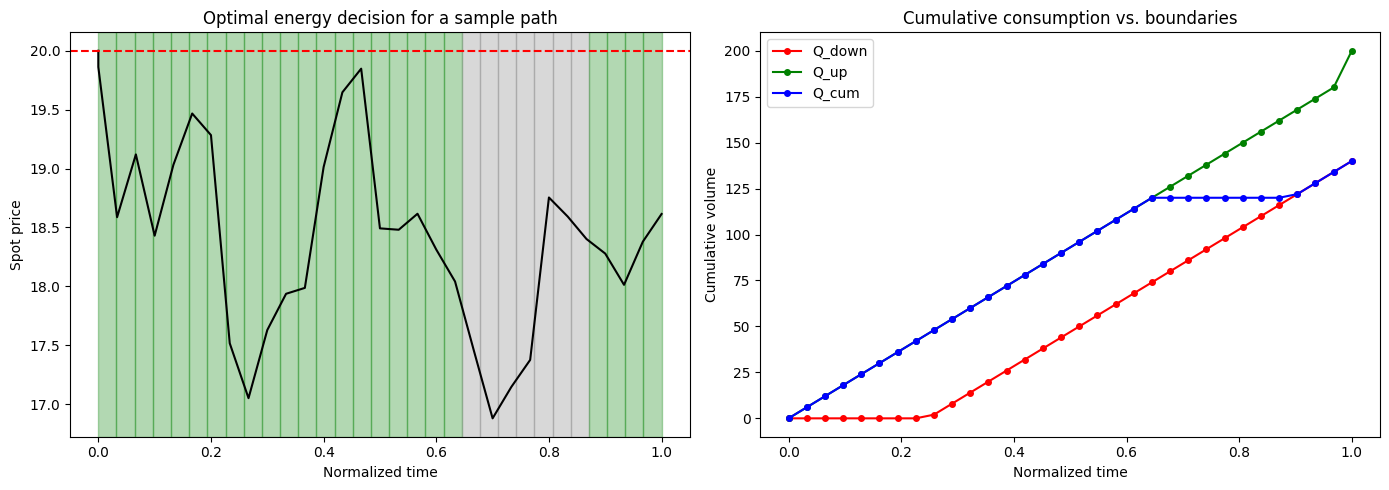

In [ ]:
plot_sample_path(
    method='PV',
    model=model,
    param_optim=theta,
    contract=contract,
    rng = rng
)

In [ ]:
N = 366
F0 = 20
lambd = 4.0
sigmaF = 0.7
T = 1
model = OneFactor(dict(F0 = F0, N = N, T = T,lambd = lambd, sigmaF = sigmaF,rng = rng))
contract = Contract(n = N - 1,Qmin = 1300,Qmax = 1900,qmin = 0,qmax = 6,K = 20, T = T)

In [ ]:
theta = nn.Parameter(torch.randn(contract.n, 3, device='cpu'))
train(method='PV', model = model, param_optim = theta,optimizer='Adam',batch_size=2**14,n_iter=40,contract=contract,transfer_params={
        'factor':12,
        'N':366,
        'M_pretrain':2**14,
        'n_iter_pretrain':100
    },lr=0.1)

Training - PV: 100%|██████████| 40/40 [00:24<00:00,  1.65it/s]


(3.4554977416992188, 24.22103524208069)

In [ ]:
round_dict(evaluate_strategy(
    method='PV',
    model=model,
    param_optim=theta,
    contract=contract,
    M=10**6,
    antithetic=True
))

{'price': 2657.44,
 'ic': (2655.64, 2659.24),
 'var': 843961.88,
 'price_bb': 2675.48,
 'ic_bb': (2673.68, 2677.27),
 'var_bb': 836911.31}

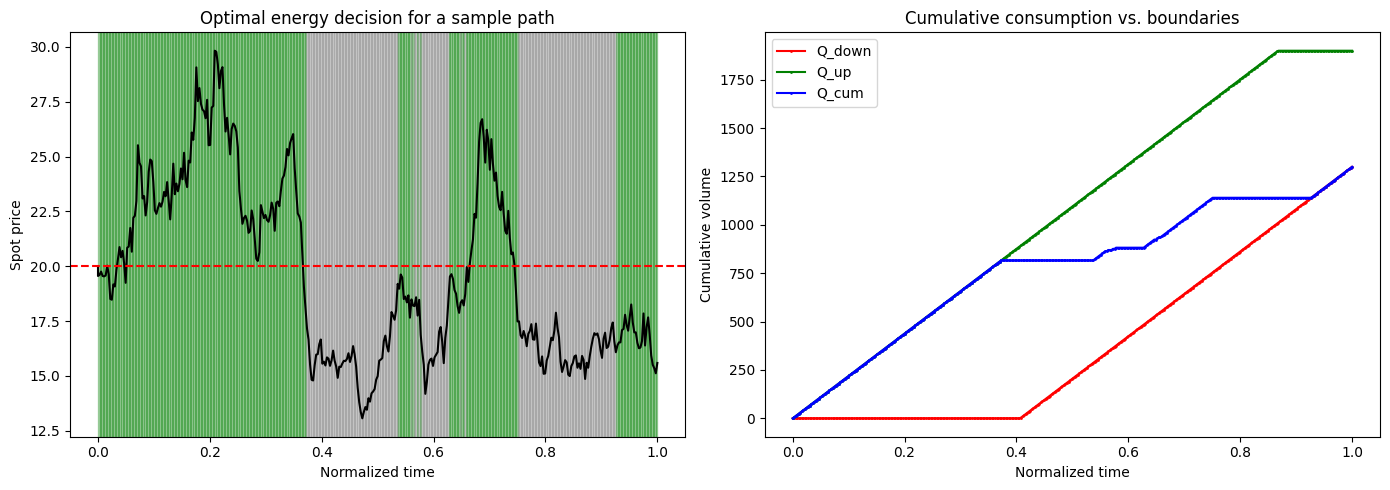

In [ ]:
plot_sample_path(
    method='PV',
    model=model,
    param_optim=theta,
    contract=contract,
    markersize = 1,
    rng = rng
)

In [ ]:
N = 32
F0 = 20
lambd = 4.0
sigmaF = 0.7
T = 1/12
model = OneFactor(dict(F0 = F0, N = N, T = T,lambd = lambd, sigmaF = sigmaF,rng = rng))
contract = Contract(n = N - 1,Qmin = 140,Qmax = 200,qmin = 0,qmax = 6,K = 20, T = T)

In [ ]:
net=SimpleNet(3,32).to(device)
train(method='NN', model = model, param_optim = net,optimizer='Adam',batch_size=2**14,n_iter=200,contract=contract,lr=0.01)

Training - NN: 100%|██████████| 200/200 [00:12<00:00, 15.83it/s]


(2.384185791015625e-07, 12.634174346923828)

In [ ]:
round_dict(evaluate_strategy(
    method='NN',
    model=model,
    param_optim=net,
    contract=contract,
    M=10**6,
    antithetic=True
))

{'price': 63.15,
 'ic': (63.08, 63.22),
 'var': 1311.02,
 'price_bb': 63.22,
 'ic_bb': (63.15, 63.29),
 'var_bb': 1315.06}

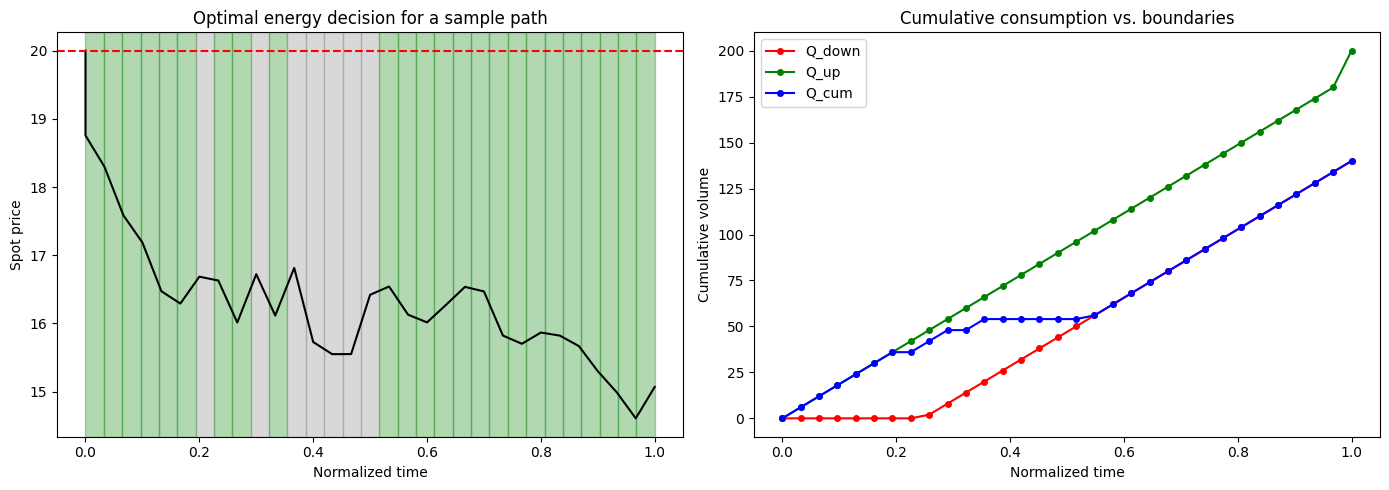

In [ ]:
plot_sample_path(
    method='NN',
    model=model,
    param_optim=net,
    contract=contract,
    rng = rng
)

## Numerical experiments

In [21]:
def run_experiment(
    config: Dict[str, Any],
    R: int = 100,
    param_optim: Optional[Any] = None
) -> pd.DataFrame:
    """
    Run R replicates of a single experiment configuration,
    measuring Tagg, Ttrain, Teval, price±IC and variance,
    and bang-bang price±IC and variance.

    Args:
        config (dict): Experiment configuration with keys:
            - 'sim': Simulation model instance (fresh or deepcopy inside).
            - 'contract': Contract instance.
            - 'method': 'PV' or 'NN'.
            - 'optimizer': 'Adam' or 'pSGLD'.
            - 'batch_size_train': int
            - 'n_iter_train': int
            - 'transfer_params': dict or None
            - 'optimizer_params': dict of kwargs for the optimizer
            - 'M_eval': int
            - 'antithetic': bool
            - optional 'features': torch.Tensor for NN evaluation
            - optional 'input_dim': int (dimensionality of input to NN)
            - optional 'device': str or torch.device
        R (int): Number of replications.
        param_optim: If provided, use this as the initial model parameters
                     for every replication; otherwise initialize fresh each time.

    Returns:
        pd.DataFrame: Each row has columns:
            rep,
            T_agg, T_train, T_eval,
            price, var, ic_lo, ic_hi,
            price_bb, var_bb, ic_bb_lo, ic_bb_hi
    """
    records = []

    for rep in range(1, R + 1):
        # 1) instantiate simulator and contract
        sim = config['sim']
        contract = config['contract']

        # 2) initialize or reuse parameters
        if param_optim is None:
            if config['method'] == 'PV':
                # PV: theta of shape (n, 3)
                theta = nn.Parameter(
                    torch.randn(contract.n, 3, device='cpu'),
                    requires_grad=True
                )
                current_param = theta
            else:
                # NN: simple MLP with input_dim (default 3), hidden 10, output 3
                input_dim = config.get('input_dim', 3)
                net = nn.Sequential(
                    nn.Linear(input_dim, 10),
                    nn.ReLU(),
                    nn.Linear(10, 10),
                    nn.ReLU(),
                    nn.Linear(10, 3)
                ).to(device)
                current_param = net
        else:
            # reuse provided param_optim
            current_param = param_optim


        # 3) training
        T_agg, T_train = train(
            method=config['method'],
            model=sim,
            param_optim=current_param,
            optimizer=config['optimizer'],
            batch_size=config['batch_size_train'],
            n_iter=config['n_iter_train'],
            contract=contract,
            transfer_params=config.get('transfer_params', None),
            use_X=config.get('use_X', False),
            **config.get('optimizer_params', {})
        )

        # 4) evaluation
        t0 = time.time()
        out = evaluate_strategy(
            method=config['method'],
            model=sim,
            param_optim=current_param,
            contract=contract,
            M=config['M_eval'],
            antithetic=config['antithetic'],
            use_X=config.get('use_X', False)
        )
        T_eval = time.time() - t0

        # 5) record results
        records.append({
            'rep':       rep,
            'T_agg':     round(T_agg,    2),
            'T_train':   round(T_train,  2),
            'T_eval':    round(T_eval,   2),
            'price':     out['price'],
            'var':       out['var'],
            'ic':     out['ic'],
            'price_bb':  out['price_bb'],
            'var_bb':    out['var_bb'],
            'ic_bb':  out['ic_bb'],
            'param_optim': current_param
        })

    return pd.DataFrame.from_records(records)

### Adam vs pSGLD

In [ ]:
R = 1
batch_size = 2**14
lr = 0.1
M_eval = 10**6
n_iters = [1000, 3000]

optimizers = ['Adam', 'pSGLD']
methods = ['PV','NN']
N = 32
F0 = 20
lambd = 4.0
sigmaF = 0.7
T = 1/12
model = OneFactor(dict(F0 = F0, N = N, T = T,lambd = lambd, sigmaF = sigmaF,rng = rng))
contract = Contract(n = N - 1,Qmin = 140,Qmax = 200,qmin = 0,qmax = 6,K = 20, T = T)

configs_Adam = []
configs_pSGLD = []

for method in methods:
    for n_iter in n_iters:
      configs_Adam.append({
            'name': f'{method}_Adam_{n_iter}',
            'method': method,
            'sim': model,
            'contract': contract,
            'M_eval': M_eval,
            'antithetic': True,
            'optimizer': 'Adam',
            'optimizer_params': {'lr': lr},
            'transfer_params': None,
            'batch_size_train': batch_size,
            'n_iter_train': n_iter})

for method in methods:
    for beta, sigma in [(0.8,1e-6), (0.9, 1e-6), (0.9,1e-5)]:
      configs_pSGLD.append({
            'name': f'{method}_pSGLD_{beta}_{int(-np.log10(sigma))}',
            'method': method,
            'sim': model,
            'contract': contract,
            'M_eval': M_eval,
            'antithetic': True,
            'optimizer': 'pSGLD',
            'optimizer_params': {'lr': lr, 'beta': beta, 'sigma': sigma, 'Lambda': 1e-10},
            'transfer_params': None,
            'batch_size_train': batch_size,
            'n_iter_train': n_iters[0]})


In [ ]:
res_Adam = {}
for config in configs_Adam:
  print(config['name'])
  res_Adam[config['name']] = run_experiment(config, R=R)

PV_Adam_1000


Training - PV: 100%|██████████| 1000/1000 [00:45<00:00, 22.17it/s]


PV_Adam_3000


Training - PV: 100%|██████████| 3000/3000 [02:17<00:00, 21.84it/s]


NN_Adam_1000


Training - NN: 100%|██████████| 1000/1000 [01:04<00:00, 15.47it/s]


NN_Adam_3000


Training - NN: 100%|██████████| 3000/3000 [03:17<00:00, 15.21it/s]


In [ ]:
if R == 1:
  print(res_Adam)

{'PV_Adam_1000':    rep  T_agg  T_train  T_eval      price          var             ic  \
0    1    0.0    45.12    5.58  63.330002  1292.940796  (63.26, 63.4)   

    price_bb       var_bb           ic_bb  \
0  63.459999  1319.120728  (63.38, 63.53)   

                                         param_optim  
0  [[tensor(1.2772, grad_fn=<UnbindBackward0>), t...  , 'PV_Adam_3000':    rep  T_agg  T_train  T_eval  price          var             ic   price_bb  \
0    1    0.0   137.39     5.3  63.43  1299.115723  (63.36, 63.5)  63.470001   

        var_bb           ic_bb  \
0  1312.291504  (63.39, 63.54)   

                                         param_optim  
0  [[tensor(-0.3811, grad_fn=<UnbindBackward0>), ...  , 'NN_Adam_1000':    rep  T_agg  T_train  T_eval      price          var              ic  \
0    1    0.0    64.65    2.76  63.580002  1262.289917  (63.51, 63.65)   

    price_bb       var_bb           ic_bb  \
0  63.580002  1263.488525  (63.51, 63.65)   

                     

In [ ]:
if R>1:
  for method in methods:
    for n_iter in n_iters:
      print(f"\n{method}_Adam_{n_iter}")
      print("\n",'price : ',round_dict(monte_carlo(res_Adam[f"{method}_Adam_{n_iter}"]["price"].values)))
      print("\n", 'price bb',round_dict(monte_carlo(res_Adam[f"{method}_Adam_{n_iter}"]["price_bb"].values)))
      print("\n", 'T_agg', round(res_Adam[f"{method}_Adam_{n_iter}"]["T_agg"].values.mean(),2),
            'T_train', round(res_Adam[f"{method}_Adam_{n_iter}"]["T_train"].values.mean(),2),
            'T_eval', round(res_Adam[f"{method}_Adam_{n_iter}"]["T_eval"].values.mean(),2))

In [ ]:
res_pSGLD = {}
for config in configs_pSGLD:
  print(config['name'])
  res_pSGLD[config['name']] = run_experiment(config, R=R)

PV_pSGLD_0.8_6


Training - PV: 100%|██████████| 1000/1000 [00:47<00:00, 21.19it/s]


PV_pSGLD_0.9_6


Training - PV: 100%|██████████| 1000/1000 [00:46<00:00, 21.68it/s]


PV_pSGLD_0.9_5


...

Training - NN: 100%|██████████| 1000/1000 [01:05<00:00, 15.22it/s]


NN_pSGLD_0.9_6


Training - NN: 100%|██████████| 1000/1000 [01:06<00:00, 15.12it/s]


NN_pSGLD_0.9_5


Training - NN: 100%|██████████| 1000/1000 [01:06<00:00, 15.06it/s]


In [ ]:
if R == 1:
  print(res_pSGLD)

{'PV_pSGLD_0.8_6':    rep  T_agg  T_train  T_eval  price          var              ic  price_bb  \
0    1    0.0     47.2    5.15  63.18  1361.128052  (63.11, 63.25)     63.34   

        var_bb           ic_bb  \
0  1431.266479  (63.26, 63.41)   

                                         param_optim  
0  [[tensor(-0.4460, grad_fn=<UnbindBackward0>), ...  , 'PV_pSGLD_0.9_6':    rep  T_agg  T_train  T_eval  price          var              ic  price_bb  \
0    1    0.0    46.13    5.32  63.09  1248.647461  (63.02, 63.16)     63.43   

        var_bb          ic_bb  \
0  1321.946533  (63.36, 63.5)   

                                         param_optim  
0  [[tensor(0.5641, grad_fn=<UnbindBackward0>), t...  , 'PV_pSGLD_0.9_5':    rep  T_agg  T_train  T_eval      price          var              ic  \
0    1    0.0    47.27    5.68  62.939999  1466.688965  (62.87, 63.02)   

   price_bb       var_bb           ic_bb  \
0     63.07  1574.361816  (62.99, 63.14)   

                           

In [ ]:
if R>1:
  for method in methods:
    for beta, sigma in [(0.8,1e-6), (0.9, 1e-6), (0.9,1e-5)]:
      print(f"\n{method}_pSGLD_{beta}_{int(-np.log10(sigma))}")
      print("\n",'price : ',round_dict(monte_carlo(res_pSGLD[f"{method}_pSGLD_{beta}_{int(-np.log10(sigma))}"]["price"].values)))
      print("\n", 'price bb',round_dict(monte_carlo(res_pSGLD[f"{method}_pSGLD_{beta}_{int(-np.log10(sigma))}"]["price_bb"].values)))
      print("\n", 'T_agg', round(res_pSGLD[f"{method}_pSGLD_{beta}_{int(-np.log10(sigma))}"]["T_agg"].values.mean(),2),
            'T_train', round(res_pSGLD[f"{method}_pSGLD_{beta}_{int(-np.log10(sigma))}"]["T_train"].values.mean(),2),
            'T_eval', round(res_pSGLD[f"{method}_pSGLD_{beta}_{int(-np.log10(sigma))}"]["T_eval"].values.mean(),2))

### Transfer learning

In [ ]:
beta, sigma, Lambda = 0.8, 1e-6, 1e-10
optimizer = 'pSGLD'
methods = ['PV','NN']

R = 1
batch_size = 2**14
lr = 0.1
M_eval = 10**6
n_iters = [1000, 300]

N = 366
F0 = 20
lambd = 4.0
sigmaF = 0.7
T = 1
model = OneFactor(dict(F0 = F0, N = N, T = T,lambd = lambd, sigmaF = sigmaF,rng = rng))
contract = Contract(n = N - 1, Qmin = 1300, Qmax = 1900, qmin = 0,qmax = 6,K = 20, T = T)

transfer_paramss = [None, {
        'factor':12,
        'N':366,
        'M_pretrain':2**14,
        'n_iter_pretrain':500
    }]

configs_pSGLD2 = []

for method in methods:
  for transfer_params, n_iter in zip(transfer_paramss, n_iters):
    configs_pSGLD2.append({
          'name': f'{method}_{n_iter}',
          'method': method,
          'sim': model,
          'contract': contract,
          'M_eval': M_eval,
          'antithetic': True,
          'optimizer': optimizer,
          'optimizer_params': {'lr': lr, 'beta': beta, 'sigma': sigma, 'Lambda': Lambda},
          'transfer_params' : transfer_params,
          'batch_size_train': batch_size,
          'n_iter_train' : n_iter})

In [ ]:
res_pSGLD2 = {}
for config in configs_pSGLD2:
  if config['n_iter_train'] == 300:
    print(config['name'])
    res_pSGLD2[config['name']] = run_experiment(config, R=R)

PV_300


Training - PV: 100%|██████████| 300/300 [03:03<00:00,  1.64it/s]


NN_300


Training - NN: 100%|██████████| 300/300 [03:53<00:00,  1.29it/s]


In [ ]:
if R == 1:
  print(res_pSGLD2)

{'PV_300':    rep  T_agg  T_train  T_eval       price          var                  ic  \
0    1  18.82   183.05   79.78  2655.27002  841656.9375  (2653.47, 2657.07)   

     price_bb       var_bb               ic_bb  \
0  2677.23999  838227.1875  (2675.44, 2679.03)   

                                         param_optim  
0  [[tensor(-1.4500, grad_fn=<UnbindBackward0>), ...  , 'NN_300':    rep  T_agg  T_train  T_eval        price          var                  ic  \
0    1  27.81   233.21   33.72  2666.320068  793682.4375  (2664.58, 2668.07)   

      price_bb    var_bb               ic_bb  \
0  2666.320068  793684.0  (2664.57, 2668.07)   

                                         param_optim  
0  [Linear(in_features=3, out_features=10, bias=T...  }


In [ ]:
if R>1:
  for method in methods:
    for n_iter in n_iters:
      print(f"\n{method}_{n_iter}")
      print("\n",'price : ',round_dict(monte_carlo(res_pSGLD2[f"{method}_{n_iter}"]["price"].values)))
      print("\n", 'price bb',round_dict(monte_carlo(res_pSGLD2[f"{method}_{n_iter}"]["price_bb"].values)))
      print("\n", 'T_agg', round(res_pSGLD2[f"{method}_{n_iter}"]["T_agg"].values.mean(),2),
            'T_train', round(res_pSGLD2[f"{method}_{n_iter}"]["T_train"].values.mean(),2),
            'T_eval', round(res_pSGLD2[f"{method}_{n_iter}"]["T_eval"].values.mean(),2))

#### Shifts of market / contract settings

In [ ]:
beta, sigma, Lambda = 0.8, 1e-6, 1e-10
optimizer = 'pSGLD'
methods = ['PV','NN']

N = 366

M1 = [OneFactor(dict(F0 = 22, N = N, T = T,lambd = lambd, sigmaF = sigmaF,rng = rng)), Contract(n = N - 1, Qmin = 1300, Qmax = 1900, qmin = 0,qmax = 6,K = 20, T = T)]
M2 = [OneFactor(dict(F0 = 20, N = N, T = T,lambd = lambd, sigmaF = sigmaF,rng = rng)), Contract(n = N - 1, Qmin = 1400, Qmax = 2000, qmin = 0,qmax = 6,K = 20, T = T)]
M3 = [OneFactor(dict(F0 = 20, N = N, T = T,lambd = lambd, sigmaF = sigmaF,rng = rng)), Contract(n = N - 1, Qmin = 1300, Qmax = 1900, qmin = 0,qmax = 6,K = 18, T = T)]
cases = (M1,M2,M3)

Reuse

In [ ]:
res_pSGLD3_reuse = {}
for method in methods:
  for i,M in enumerate(cases):
    res_pSGLD3_reuse[f'{method}_M{i+1}'] = round_dict(evaluate_strategy(method=method, model=M[0],
                                                                param_optim=res_pSGLD2[f"{method}_300"]['param_optim'].values[0], contract=M[1], M=10**6, antithetic=True))

In [ ]:
res_pSGLD3_reuse

{'PV_M1': {'price': 3682.92,
  'ic': (3680.91, 3684.93),
  'var': 1053464.5,
  'price_bb': 3693.64,
  'ic_bb': (3691.63, 3695.66),
  'var_bb': 1059507.62},
 'PV_M2': {'price': 2485.6,
  'ic': (2483.92, 2487.27),
  'var': 732389.19,
  'price_bb': 2507.7,
  'ic_bb': (2506.03, 2509.37),
  'var_bb': 727062.62},
 'PV_M3': {'price': 3392.01,
  'ic': (3390.18, 3393.83),
  'var': 870470.5,
  'price_bb': 3401.3,
  'ic_bb': (3399.46, 3403.14),
  'var_bb': 879454.38},
 'NN_M1': {'price': 3760.95,
  'ic': (3758.99, 3762.91),
  'var': 997296.31,
  'price_bb': 3760.95,
  'ic_bb': (3758.99, 3762.91),
  'var_bb': 997298.38},
 'NN_M2': {'price': 2486.08,
  'ic': (2484.45, 2487.71),
  'var': 692253.06,
  'price_bb': 2486.08,
  'ic_bb': (2484.45, 2487.71),
  'var_bb': 692252.44},
 'NN_M3': {'price': 3484.26,
  'ic': (3482.48, 3486.04),
  'var': 827845.44,
  'price_bb': 3484.26,
  'ic_bb': (3482.47, 3486.04),
  'var_bb': 827845.38}}

Retrain

In [ ]:
R = 1
batch_size = 2**14
lr = 0.1
M_eval = 10**6
n_iter = 300


transfer_params = None

configs_pSGLD3 = []

for method in methods:
  for i, (model, contract) in enumerate(cases):
    configs_pSGLD3.append({
            'name': f'{method}_M{i+1}',
            'method': method,
            'sim': model,
            'contract': contract,
            'M_eval': M_eval,
            'antithetic': True,
            'optimizer': optimizer,
            'optimizer_params': {'lr': lr, 'beta': beta, 'sigma': sigma, 'Lambda': Lambda},
            'transfer_params' : transfer_params,
            'batch_size_train': batch_size,
            'n_iter_train' : n_iter,
            'param_optim': res_pSGLD2[f"{method}_300"]['param_optim'].values[0]})

In [ ]:
res_pSGLD3 = {}
for config in configs_pSGLD3:
  print(config['name'])
  res_pSGLD3[config['name']] = run_experiment(config, R=R, param_optim = config['param_optim'] )

PV_M1


Training - PV: 100%|██████████| 300/300 [02:42<00:00,  1.84it/s]


PV_M2


Training - PV: 100%|██████████| 300/300 [02:52<00:00,  1.74it/s]


PV_M3


...

Training - NN: 100%|██████████| 300/300 [03:54<00:00,  1.28it/s]


NN_M2


Training - NN: 100%|██████████| 300/300 [03:54<00:00,  1.28it/s]


NN_M3


Training - NN: 100%|██████████| 300/300 [03:54<00:00,  1.28it/s]


In [ ]:
if R==1:
  print(res_pSGLD3)

{'PV_M1':    rep  T_agg  T_train  T_eval        price          var                  ic  \
0    1    0.0   162.63   76.29  3788.330078  937831.6875  (3786.44, 3790.23)   

      price_bb       var_bb              ic_bb  \
0  3798.300049  933854.4375  (3796.41, 3800.2)   

                                         param_optim  
0  [[tensor(-2.0258, grad_fn=<UnbindBackward0>), ...  , 'PV_M2':    rep  T_agg  T_train  T_eval        price          var                  ic  \
0    1    0.0   172.62   78.32  2498.189941  713214.6875  (2496.54, 2499.85)   

     price_bb       var_bb               ic_bb  \
0  2512.76001  708442.4375  (2511.11, 2514.41)   

                                         param_optim  
0  [[tensor(-2.0258, grad_fn=<UnbindBackward0>), ...  , 'PV_M3':    rep  T_agg  T_train  T_eval       price          var                  ic  \
0    1    0.0   171.68   81.13  3534.47998  752679.3125  (3532.78, 3536.18)   

     price_bb       var_bb               ic_bb  \
0  3541.77002  74

In [ ]:
if R>1:
  for method in methods:
    for M in ["M1", "M2", "M3"]:
      print(f"\n{method}_{M}")
      print("\n",'price : ',round_dict(monte_carlo(res_pSGLD3[f"{method}_{M}"]["price"].values)))
      print("\n", 'price bb',round_dict(monte_carlo(res_pSGLD3[f"{method}_{M}"]["price_bb"].values)))
      print("\n", 'T_agg', round(res_pSGLD3[f"{method}_{M}"]["T_agg"].values.mean(),2),
            'T_train', round(res_pSGLD3[f"{method}_{M}"]["T_train"].values.mean(),2),
            'T_eval', round(res_pSGLD3[f"{method}_{M}"]["T_eval"].values.mean(),2))

## Sensitivity with respect to the initial forward price $F_0$

In [12]:
def deltas_NN(net: nn.Module, S: torch.Tensor, contract: Contract) -> list:
    """
    Calculate the deltas of the NN priced swing option with respect to the initial values of the forward curve, Equation (4.2).

    Args:
        net (nn.Module): The trained Neural Network model.
        S (torch.Tensor): Tensor of simulated spot prices with shape (batch_size, n), where n is the number of periods.
        contract: The contract object containing contract parameters (e.g., `n`, `K`).

    Returns:
        list: A list of deltas for each period
    """
    deltas = []  # List to store the deltas for each period
    Q = torch.zeros_like(S[:, 0])  # Initialize the accumulated quantity to zeros

    # Loop through each maturity
    for l in range(contract.n):
        q = q_NN_BG(net, l, Q, S[:, l], contract)  # Get the exercised volume at period l
        deltas.append((q * S[:, l] / F0).mean().item())  # Calculate and store the delta
        Q += q  # Update the accumulated quantity

    return deltas


def deltas_PV(theta: torch.Tensor, S: torch.Tensor, contract: Contract) -> list:
    """
    Calculate the deltas of the PV priced swing option with respect to the initial values of the forward curve, Equation (4.2).

    Args:
        net (nn.Module): The trained Neural Network model.
        S (torch.Tensor): Tensor of simulated spot prices with shape (batch_size, n), where n is the number of periods.
        contract: The contract object containing contract parameters (e.g., `n`, `K`).

    Returns:
        list: A list of deltas for each period
    """
    deltas = []  # List to store the deltas for each period
    Q = torch.zeros_like(S[:, 0])  # Initialize the accumulated quantity to zeros

    # Loop through each maturity period
    for l in range(contract.n):
        q = q_PV(theta[l, :], l, Q, S[:, l], contract)  # Get the exercised volume at period l
        deltas.append((q * S[:, l] / F0).mean().item())  # Calculate and store the delta
        Q += q  # Update the accumulated quantity

    return deltas


In [19]:
beta, sigma, Lambda = 0.8, 1e-6, 1e-10
N = 32
F0 = 20
lambd = 4.0
sigmaF = 0.7
T = 1/12
model_case1 = OneFactor(dict(F0 = F0, N = N, T = T,lambd = lambd, sigmaF = sigmaF,rng = rng))
contract_case1 = Contract(n = N - 1,Qmin = 140,Qmax = 200,qmin = 0,qmax = 6,K = 20, T=T)
theta_case1 = nn.Parameter(torch.randn(contract_case1.n, 3, device='cpu'))
train(method='PV', model = model_case1, param_optim = theta_case1,optimizer='pSGLD',batch_size=2**14,n_iter=1000,contract=contract_case1,lr=0.1,
      beta = beta, sigma = sigma, Lambda = Lambda)
net_case1 = nn.Sequential(
    nn.Linear(3,10), nn.ReLU(),
    nn.Linear(10,10), nn.ReLU(),
    nn.Linear(10,3)
).to(device)
train(method='NN', model = model_case1, param_optim = net_case1,optimizer='pSGLD',batch_size=2**14,n_iter=1000,contract=contract_case1,lr=0.1,
      beta = beta, sigma = sigma, Lambda = Lambda)

Training - NN: 100%|██████████| 1000/1000 [01:07<00:00, 14.91it/s]


(7.152557373046875e-07, 67.08432412147522)

In [27]:
N = 366
F0 = 20
lambd = 4.0
sigmaF = 0.7
T = 1
model_case2 = OneFactor(dict(F0 = F0, N = N, T = T,lambd = lambd, sigmaF = sigmaF,rng = rng))
contract_case2 = Contract(n = N - 1,Qmin = 1300,Qmax = 1900,qmin = 0,qmax = 6,K = 20, T = T)
theta_case2 = nn.Parameter(torch.randn(contract_case2.n, 3, device='cpu'))
transfer_params = {
    'factor':12,
    'N':366,
    'M_pretrain':2**14,
    'n_iter_pretrain':500
}
train(method='PV', model = model_case2, param_optim = theta_case2,optimizer='pSGLD',batch_size=2**14,n_iter=300,
      contract=contract_case2,transfer_params=transfer_params,lr=0.1,beta = beta, sigma = sigma, Lambda = Lambda)
net_case2 = nn.Sequential(
    nn.Linear(3,10), nn.ReLU(),
    nn.Linear(10,10), nn.ReLU(),
    nn.Linear(10,3)
).to(device)
train(method='NN', model = model_case2, param_optim = net_case2,optimizer='pSGLD',batch_size=2**14,n_iter=300,
      contract=contract_case2,transfer_params=transfer_params,lr=0.1,beta = beta, sigma = sigma, Lambda = Lambda)

Training - NN: 100%|██████████| 300/300 [03:56<00:00,  1.27it/s]


(29.290202617645264, 236.25289130210876)

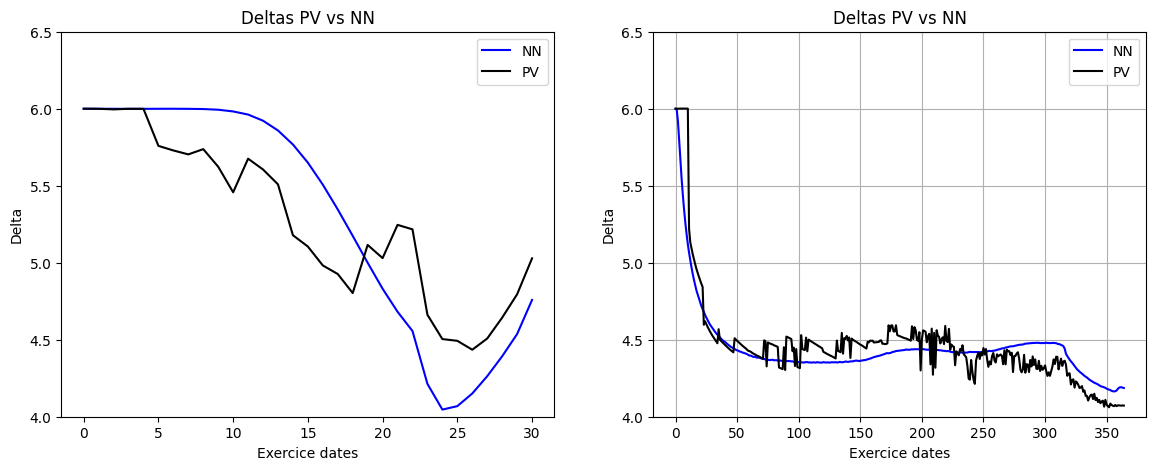

In [29]:
with torch.no_grad():
    S_case1 = model_case1.sim(10**6)
    x1 = np.arange(0,32)
    dNN1 = deltas_NN(net_case1, S_case1.to(device), contract_case1)  # Deltas for Neural Network method
    dPV1 = deltas_PV(theta_case1, S_case1, contract_case1)  # Deltas for Physical Volume method

    S_case2 = model_case2.sim(10**6)
    x2 = np.arange(0,366)
    dNN2 = deltas_NN(net_case2, S_case2.to(device), contract_case2)  # Deltas for Neural Network method
    dPV2 = deltas_PV(theta_case2, S_case2, contract_case2)  # Deltas for Physical Volume method
    # Plot the results
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot(x1[:-1], dNN1, label='NN', color='blue')
    ax1.plot(x1[:-1], dPV1, label='PV', color='black')
    ax1.set_ylim(4,6.5)
    ax2.set_ylim(4,6.5)
    ax1.set_xlabel("Exercice dates")
    ax1.set_ylabel("Delta")
    ax1.set_title("Deltas PV vs NN")
    ax1.legend()

    ax2.plot(x2[:-1], dNN2, label='NN', color='blue')
    ax2.plot(x2[:-1], dPV2, label='PV', color='black')
    ax2.set_xlabel("Exercice dates")
    ax2.set_ylabel("Delta")
    ax2.set_title("Deltas PV vs NN")
    ax2.legend()
    plt.legend()
    plt.grid(True)
    plt.show()

## Three factor model

In [30]:
beta, sigma, Lambda = 0.8, 1e-6, 1e-10
R = 1
batch_size = 2**14
lr = 0.1
M_eval = 10**6
n_iter = 1000

optimizer = 'pSGLD'
methods = ['PV','NN']
N = 32
F0 = 20
lambd = torch.full((3,), 1.5)
sigmaF = torch.full((3,), 0.7)
T = 1/12

rhos = [0.6, 0.3, -0.2]
correls = {}
for rho in rhos:
  correls[rho] = torch.tensor([[1, rho, rho], [rho, 1, rho], [rho, rho, 1]])


contract = Contract(n = N - 1,Qmin
 = 140,Qmax = 200,qmin = 0,qmax = 6,K = 20, T = T)


configs_3_factor = []


for method in methods:
  for rho in rhos:
    model = ThreeFactor(dict(F0 = F0, N = N, T = T,lambd = lambd, sigmaF = sigmaF,rng = rng, correl = correls[rho]))
    configs_3_factor.append({
            'name': f'{method}_{rho}',
            'method': method,
            'sim': model,
            'contract': contract,
            'M_eval': M_eval,
            'antithetic': True,
            'optimizer': 'pSGLD',
            'optimizer_params': {'lr': lr, 'beta': beta, 'sigma': sigma, 'Lambda': Lambda},
            'transfer_params': None,
            'batch_size_train': batch_size,
            'n_iter_train': n_iter})


In [31]:
res_3_factor = {}
for config in configs_3_factor:
  print(config['name'])
  res_3_factor[config['name']] = run_experiment(config, R=R)

PV_0.6


Training - PV: 100%|██████████| 1000/1000 [01:26<00:00, 11.59it/s]


PV_0.3


Training - PV: 100%|██████████| 1000/1000 [01:25<00:00, 11.75it/s]


PV_-0.2


...

Training - NN: 100%|██████████| 1000/1000 [01:49<00:00,  9.13it/s]


NN_0.3


Training - NN: 100%|██████████| 1000/1000 [01:49<00:00,  9.10it/s]


NN_-0.2


Training - NN: 100%|██████████| 1000/1000 [01:49<00:00,  9.12it/s]


In [32]:
if R ==1:
  print(res_3_factor)

{'PV_0.6':    rep  T_agg  T_train  T_eval       price           var               ic  \
0    1    0.0    86.26   12.72  167.410004  26075.173828  (167.1, 167.73)   

     price_bb        var_bb             ic_bb  \
0  167.410004  27077.230469  (167.08, 167.73)   

                                         param_optim  
0  [[tensor(1.2286, grad_fn=<UnbindBackward0>), t...  , 'PV_0.3':    rep  T_agg  T_train  T_eval       price           var                ic  \
0    1    0.0     85.1   12.77  143.429993  14738.794922  (143.19, 143.67)   

     price_bb        var_bb             ic_bb  \
0  143.850006  15177.383789  (143.61, 144.09)   

                                         param_optim  
0  [[tensor(-0.2905, grad_fn=<UnbindBackward0>), ...  , 'PV_-0.2':    rep  T_agg  T_train  T_eval      price          var              ic  \
0    1    0.0    86.82   12.95  88.419998  4041.208984  (88.29, 88.54)   

    price_bb       var_bb          ic_bb  \
0  88.529999  4214.339355  (88.4, 88.65)   

In [33]:
if R>1:
  for method in methods:
    for rho in rhos:
      print(f"\n{method}_{rho}")
      print("\n",'price : ',round_dict(monte_carlo(res_3_factor[f"{method}_{rho}"]["price"].values)))
      print("\n", 'price bb',round_dict(monte_carlo(res_3_factor[f"{method}_{rho}"]["price_bb"].values)))
      print("\n", 'T_agg', round(res_3_factor[f"{method}_{rho}"]["T_agg"].values.mean(),2),
            'T_train', round(res_3_factor[f"{method}_{rho}"]["T_train"].values.mean(),2),
            'T_eval', round(res_3_factor[f"{method}_{rho}"]["T_eval"].values.mean(),2))


In [34]:
res_3_factor_X = {}
for config in configs_3_factor:
  if config['method'] == 'NN':
    print(config['name'])
    config['input_dim'] = 3+3
    config['use_X'] = True
    res_3_factor_X[config['name']] = run_experiment(config, R=R)

NN_0.6


Training - NN: 100%|██████████| 1000/1000 [01:51<00:00,  8.98it/s]


NN_0.3


Training - NN: 100%|██████████| 1000/1000 [01:51<00:00,  8.97it/s]


NN_-0.2


Training - NN: 100%|██████████| 1000/1000 [01:51<00:00,  8.94it/s]


In [35]:
if R==1:
  print(res_3_factor_X)

{'NN_0.6':    rep  T_agg  T_train  T_eval       price           var               ic  \
0    1    0.0   111.35   10.07  164.360001  30264.707031  (164.02, 164.7)   

     price_bb        var_bb            ic_bb  \
0  164.360001  30265.367188  (164.02, 164.7)   

                                         param_optim  
0  [Linear(in_features=6, out_features=10, bias=T...  , 'NN_0.3':    rep  T_agg  T_train  T_eval       price           var               ic  \
0    1    0.0   111.45   10.14  143.029999  13481.381836  (142.8, 143.26)   

     price_bb        var_bb            ic_bb  \
0  143.029999  13481.458008  (142.8, 143.26)   

                                         param_optim  
0  [Linear(in_features=6, out_features=10, bias=T...  , 'NN_-0.2':    rep  T_agg  T_train  T_eval      price          var              ic  \
0    1    0.0   111.81    9.95  88.440002  4147.290527  (88.31, 88.57)   

    price_bb       var_bb           ic_bb  \
0  88.440002  4147.286621  (88.31, 88.57)   

  

In [36]:
if R>1:
  for rho in rhos:
    print(f"\nNN_{rho}")
    print("\n",'price : ',round_dict(monte_carlo(res_3_factor_X[f"NN_{rho}"]["price"].values)))
    print("\n", 'price bb',round_dict(monte_carlo(res_3_factor_X[f"NN_{rho}"]["price_bb"].values)))
    print("\n", 'T_agg', round(res_3_factor_X[f"NN_{rho}"]["T_agg"].values.mean(),2),
            'T_train', round(res_3_factor_X[f"NN_{rho}"]["T_train"].values.mean(),2),
            'T_eval', round(res_3_factor_X[f"NN_{rho}"]["T_eval"].values.mean(),2))